#### Question 1

**ISLP chapter 12 exercise #2**

**Suppose that we have four observations, for which we compute a dissimilarity matrix, given by**
$$
\begin{bmatrix}
\ & 0.3 & 0.4 & 0.7 \\
0.3 & \ & 0.5 & 0.8 \\
0.4 & 0.5 & \ & 0.45 \\
0.7 & 0.8 & 0.45 & \
\end{bmatrix}
$$
**For instance, the dissimilarity between the first and second observations is $0.3$, and the dissimilarity between the second and fourth observations is $0.8$.**

**(a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observations using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.**

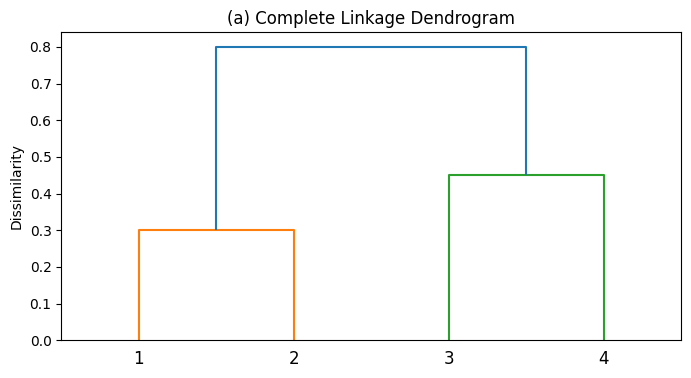

In [67]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Labels for observations
labels = ["1", "2", "3", "4"]
dists = [0.3, 0.4, 0.7, 0.5, 0.8, 0.45]

# Compute linkage matrices
link_complete = linkage(dists, method='complete')
link_single = linkage(dists, method='single')

# Plot (a): Complete linkage
plt.figure(figsize=(8, 4))
dendrogram(link_complete, labels=labels)
plt.title("(a) Complete Linkage Dendrogram")
plt.ylabel("Dissimilarity")
plt.show()

**(b) Repeat (a), this time using single linkage clustering.**

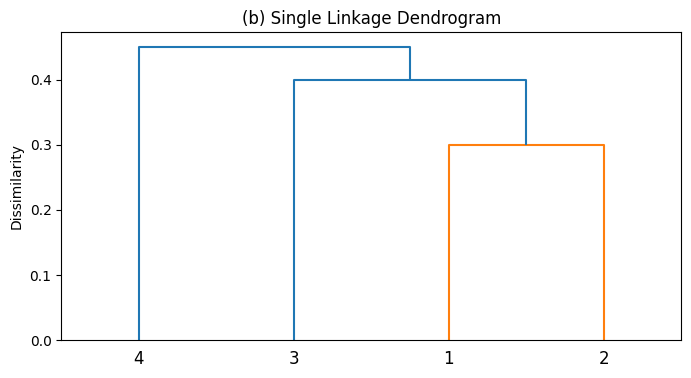

In [69]:
# Plot (b): Single linkage
plt.figure(figsize=(8, 4))
dendrogram(link_single, labels=labels)
plt.title("(b) Single Linkage Dendrogram")
plt.ylabel("Dissimilarity")
plt.show()

**(c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?**

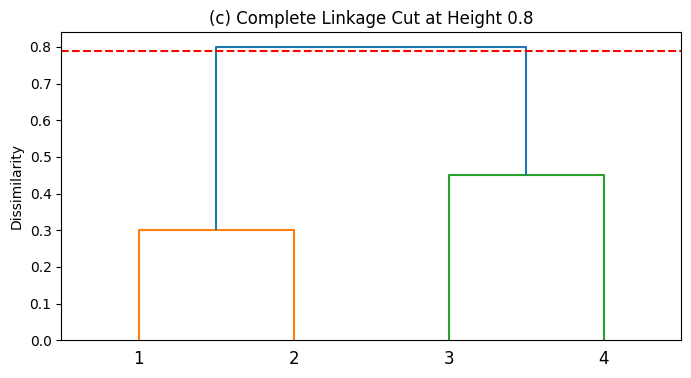

In [71]:
# Plot (c): Cut complete linkage dendrogram at height 0.8
plt.figure(figsize=(8, 4))
dendrogram(link_complete, labels=labels, color_threshold=0.79)
plt.axhline(y=0.79, c='red', ls='--')
plt.title("(c) Complete Linkage Cut at Height 0.8")
plt.ylabel("Dissimilarity")
plt.show()

**(d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?**

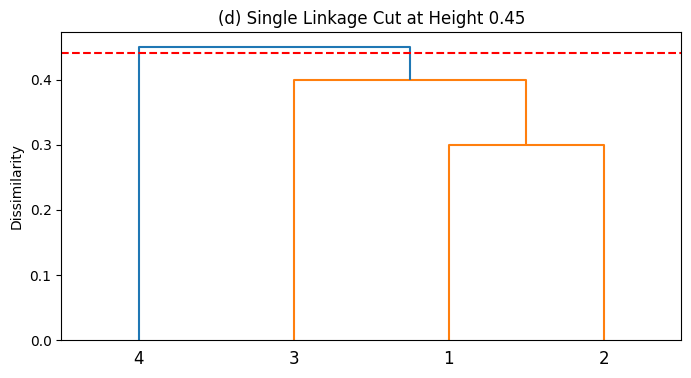

In [73]:
# Plot (d): Cut single linkage dendrogram at height 0.45
plt.figure(figsize=(8, 4))
dendrogram(link_single, labels=labels, color_threshold=0.44)
plt.axhline(y=0.44, c='red', ls='--')
plt.title("(d) Single Linkage Cut at Height 0.45")
plt.ylabel("Dissimilarity")
plt.show()

**(e) It is mentioned in this chapter that at each fusion in the dendrogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.**

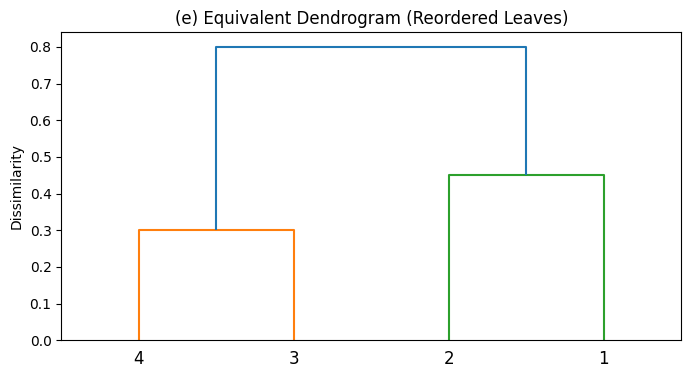

In [75]:
# Plot (e): Reordered equivalent of (a)
plt.figure(figsize=(8, 4))
dendrogram(link_complete, labels=labels[::-1])
plt.title("(e) Equivalent Dendrogram (Reordered Leaves)")
plt.ylabel("Dissimilarity")
plt.show()

#### Question 2

**Suppose that you have a dataset with two predictors and perform PCA by carrying out an eigen-decomposition on the covariance matrix of the data (the two predictors are on the same scale). You find that its two eigenvalues are $\lambda_1 = 4$ and $\lambda_2 = 1$, and their corresponding eigenvectors are**
$$
u_1 = \begin{bmatrix} 0.6 \\ 0.8 \end{bmatrix}
\quad
u_2 = \begin{bmatrix} -0.8 \\ 0.6 \end{bmatrix}
$$

**(a) Reconstruct the covariance matrix of the data.**

$$
U =
\begin{bmatrix}
0.6 & -0.8 \\
0.8 & 0.6
\end{bmatrix} \quad
\Lambda = 
\begin{bmatrix}
4 & 0 \\
0 & 1 
\end{bmatrix}
$$
$$
\Sigma = U\Sigma U^T=
\begin{bmatrix}
0.6 & -0.8 \\
0.8 & 0.6
\end{bmatrix}
\begin{bmatrix}
4 & 0 \\
0 & 1 
\end{bmatrix}
\begin{bmatrix}
0.6 & 0.8 \\
-0.8 & 0.6
\end{bmatrix} = 
\begin{bmatrix}
2.08 & 1.44 \\
1.44 & 2.92
\end{bmatrix}
$$

***

**(b) What percentage of variance is explained by the first principal component**

Percentage of variance explained by PC1 = $\cfrac{4}{4+1}=80\%$

**(c) For a new data point $X = (1,2)$, find its scores on the first and second principal components.**

- score on PC1 $=u_1^TX=[0.6,0.8]\cdot [1,2]=2.2$
- score on PC1 $=u_2^TX=[-0.8, 0.6]\cdot [1,2]=0.4$

#### Question 3

**Consider the `arrests` data, which can be downloaded from canvas.**

In [55]:
import pandas as pd
df = pd.read_csv("arrests.csv", index_col=0)
df.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


**(a) Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states. Plot the dendrogram.**

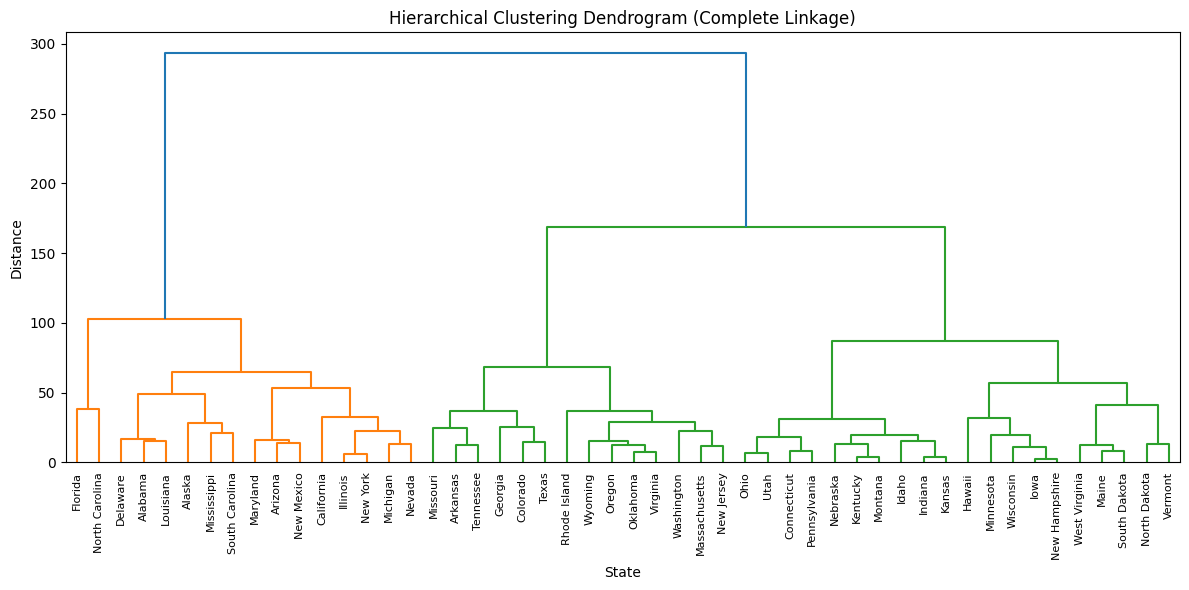

In [57]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Only numerical features
X = df.values

# Hierarchical clustering
Z = linkage(X, method='complete', metric='euclidean')

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df.index.tolist(), leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('State')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

**(b) Cut the dendrogram at a height that results in five distinct clusters. Report the states belonging to each of the five clusters. Make a silhouette coefficient plot.**


Cluster 1:
['Florida', 'North Carolina']

Cluster 2:
['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'South Carolina']

Cluster 3:
['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']

Cluster 4:
['Connecticut', 'Idaho', 'Indiana', 'Kansas', 'Kentucky', 'Montana', 'Nebraska', 'Ohio', 'Pennsylvania', 'Utah']

Cluster 5:
['Hawaii', 'Iowa', 'Maine', 'Minnesota', 'New Hampshire', 'North Dakota', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']


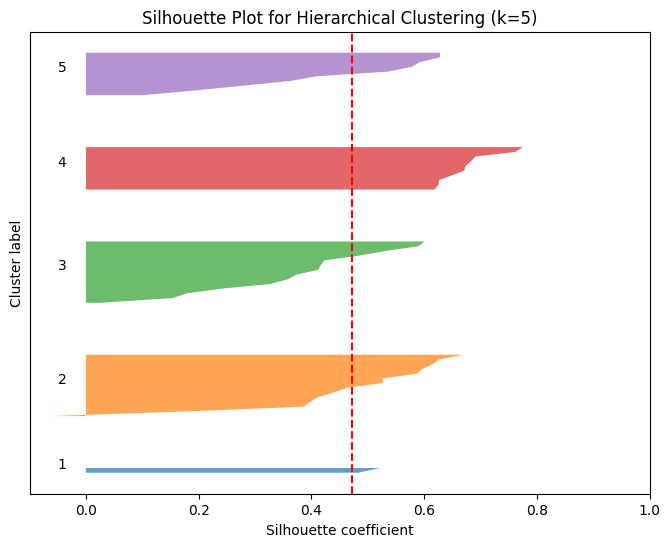

In [85]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# Cut at 5 clusters
clusters_hc = fcluster(Z, t=5, criterion='maxclust')
df['Cluster_HC'] = clusters_hc

# Report clusters
for i in range(1, 6):
    print(f"\nCluster {i}:")
    print(df[df['Cluster_HC'] == i].index.tolist())

silhouette_vals = silhouette_samples(X, clusters_hc)
df['Silhouette_HC'] = silhouette_vals

n_clusters = 5
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(8, 6)

y_lower = 10
for i in range(1, n_clusters + 1):
    cluster_silhouette_vals = silhouette_vals[clusters_hc == i]
    cluster_silhouette_vals.sort()

    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    # color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

avg_score = silhouette_score(X, clusters_hc)
ax1.axvline(x=avg_score, color="red", linestyle="--")
ax1.set_xlabel("Silhouette coefficient")
ax1.set_ylabel("Cluster label")
ax1.set_title("Silhouette Plot for Hierarchical Clustering (k=5)")
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1])
plt.show()

**(c) Perform K-means clustering on the data with $K = 5$ and report which states belong to which clusters. Report how you initialized the algorithm. Make a silhouette coefficient plot and comment on any interesting features.**


K-means Cluster 1:
['Hawaii', 'Iowa', 'Maine', 'Minnesota', 'New Hampshire', 'North Dakota', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']

K-means Cluster 2:
['Alabama', 'Alaska', 'California', 'Delaware', 'Illinois', 'Louisiana', 'Michigan', 'Mississippi', 'Nevada', 'New York']

K-means Cluster 3:
['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']

K-means Cluster 4:
['Connecticut', 'Idaho', 'Indiana', 'Kansas', 'Kentucky', 'Montana', 'Nebraska', 'Ohio', 'Pennsylvania', 'Utah']

K-means Cluster 5:
['Arizona', 'Florida', 'Maryland', 'New Mexico', 'North Carolina', 'South Carolina']


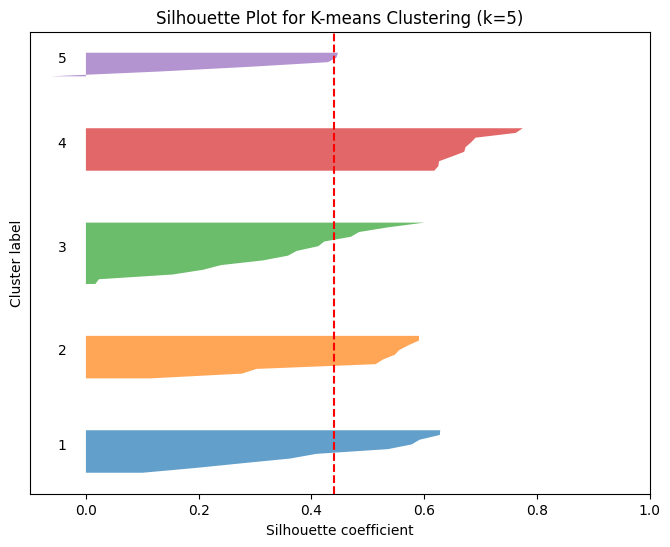

In [93]:
from sklearn.cluster import KMeans

# K-means clustering
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
clusters_km = kmeans.fit_predict(X)

df['Cluster_KM'] = clusters_km + 1  # optional: to match cluster IDs with (b)

# Report clusters
for i in range(1, 6):
    print(f"\nK-means Cluster {i}:")
    print(df[df['Cluster_KM'] == i].index.tolist())

# Silhouette plot
silhouette_vals_km = silhouette_samples(X, clusters_km)
df['Silhouette_KM'] = silhouette_vals_km

n_clusters = 5
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(8, 6)

y_lower = 10
for i in range(1, n_clusters+1):
    ith_cluster_silhouette_vals = silhouette_vals_km[clusters_km == i-1]
    ith_cluster_silhouette_vals.sort()
    
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_vals, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

avg_score_km = silhouette_score(X, clusters_km)
ax1.axvline(x=avg_score_km, color="red", linestyle="--")

ax1.set_xlabel("Silhouette coefficient")
ax1.set_ylabel("Cluster label")
ax1.set_title("Silhouette Plot for K-means Clustering (k=5)")
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1])
plt.show()

- Cluster 5 looks like a clean group of southeastern U.S. states, geographically and possibly demographically similar.
- Cluster 4 includes a variety of inland or Midwestern states, maybe more economically aligned.
- Cluster 3 & 2 include a blend of east/west coast and economically diverse states, which seems hard to separate clearly.

**(d) Scale the variables to have mean 0 and standard deviation 1. Repeat questions (a)–(c) using the scaled data.**

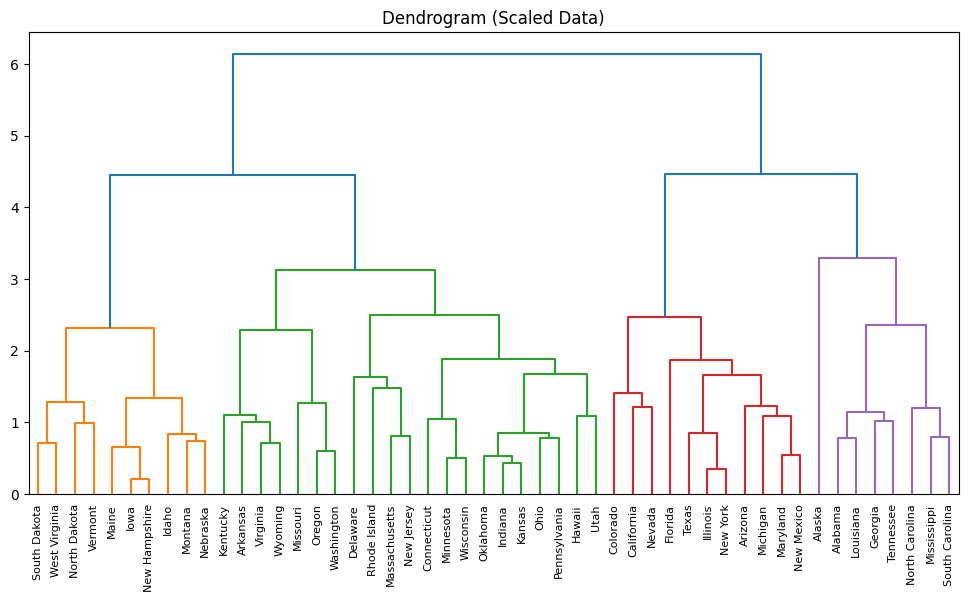

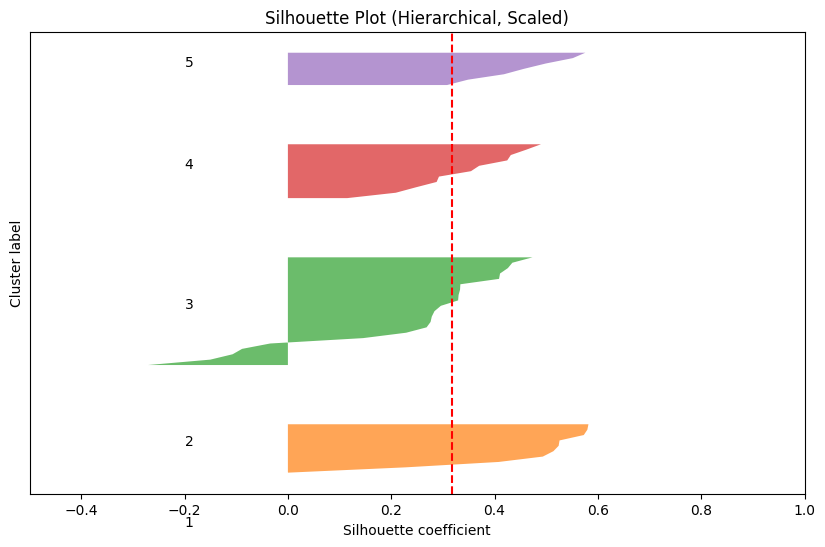

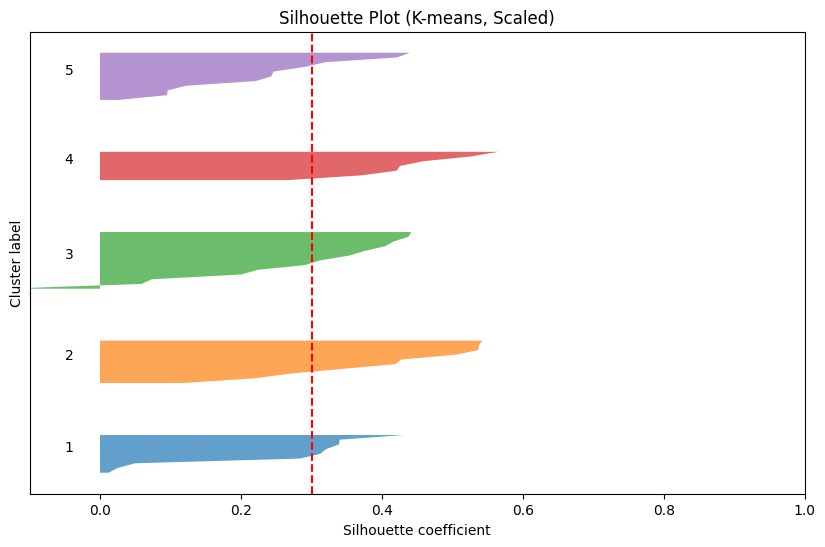

In [127]:
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :4])

# Redo hierarchical clustering
Z_scaled = linkage(X_scaled, method='complete', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Z_scaled, labels=df.index.tolist(), leaf_rotation=90)
plt.title('Dendrogram (Scaled Data)')
plt.show()

# Cut into 5 clusters
clusters_hc_scaled = fcluster(Z_scaled, t=5, criterion='maxclust')
df['Cluster_HC_Scaled'] = clusters_hc_scaled

# Silhouette for HC (scaled)
silhouette_vals_scaled = silhouette_samples(X_scaled, clusters_hc_scaled)
df['Silhouette_HC_Scaled'] = silhouette_vals_scaled

cluster_labels = np.unique(clusters_hc_scaled)  # ✅ 使用真实 label
n_clusters_hc = len(cluster_labels)
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 6)

y_lower = 10
for i in cluster_labels:
    ith_silhouette_vals = silhouette_vals_scaled[clusters_hc_scaled == i-1]
    ith_silhouette_vals.sort()
    
    size_i = ith_silhouette_vals.shape[0]
    y_upper = y_lower + size_i

    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_silhouette_vals, alpha=0.7)

    ax1.text(-0.2, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

avg_score_scaled_hc = silhouette_score(X_scaled, clusters_hc_scaled)
ax1.axvline(x=avg_score_scaled_hc, color="red", linestyle="--")

ax1.set_xlabel("Silhouette coefficient")
ax1.set_ylabel("Cluster label")
ax1.set_title("Silhouette Plot (Hierarchical, Scaled)")
ax1.set_yticks([])
ax1.set_xlim([-0.5, 1])
plt.show()

# K-means on scaled
kmeans_scaled = KMeans(n_clusters=5, n_init=10, random_state=42)
clusters_km_scaled = kmeans_scaled.fit_predict(X_scaled)
df['Cluster_KM_Scaled'] = clusters_km_scaled + 1

# Silhouette for K-means (scaled)
silhouette_vals_km_scaled = silhouette_samples(X_scaled, clusters_km_scaled)
df['Silhouette_KM_Scaled'] = silhouette_vals_km_scaled

fig, ax2 = plt.subplots(1, 1)
fig.set_size_inches(10, 6)

y_lower = 10
for i in range(1, 6):
    ith_vals = silhouette_vals_km_scaled[clusters_km_scaled == (i - 1)]  # 原始标签从 0 开始
    ith_vals.sort()

    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    ax2.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_vals, alpha=0.7)

    ax2.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

avg_score_scaled_km = silhouette_score(X_scaled, clusters_km_scaled)
ax2.axvline(x=avg_score_scaled_km, color="red", linestyle="--")

ax2.set_xlabel("Silhouette coefficient")
ax2.set_ylabel("Cluster label")
ax2.set_title("Silhouette Plot (K-means, Scaled)")
ax2.set_yticks([])
ax2.set_xlim([-0.1, 1])
plt.show()

**(e) Run PCA on the dataset with 1, 2, and 3 PCs. Report the variance explained for each of the three PCA fits.**

In [65]:
from sklearn.decomposition import PCA

# Fit PCA on scaled data
pca = PCA()
pca.fit(X_scaled)

# Variance explained
for i in range(1, 4):
    var_explained = sum(pca.explained_variance_ratio_[:i])
    print(f"Variance explained by first {i} PC(s): {var_explained:.4f}")

Variance explained by first 1 PC(s): 0.6201
Variance explained by first 2 PC(s): 0.8675
Variance explained by first 3 PC(s): 0.9566
